Si consideri il data set Titanic composto dai file train.csv e test.csv, allegati al 
presente compito, costituiti da 891+418 record che descrivono i passeggeri del Titanic 
e li etichettano come sopravvissuti o meno sulla base delle seguenti caratteristiche: 
• PassengerId 
• Survived (1/0, solo train) 
• Pclass (1, 2, 3) 
• Name 
• Sex (‘male’, ‘female’) 
• Age (frazionaria se meno di 1; 
se stimata è nella forma xx.5) 
• SibSp  (numero  di  familiari; 
Sibling: fratelli/sorelle; 
Spouse: moglie/marito) 
• Parch  (numero  familiari; 
Parent: padre/madre;  
Child: figli/figlie;  
Parch=0 per piccoli 
accompagnati solo dalla tata) 
• Ticket 
• Fare 
• Cabin 
• Embarked (C = Cherbourg,  
Q = Queenstown,  
S = Southampton)
 
1. Individuare eventuali dati mancanti e farne l’imputazione secondo criteri che 
rispecchino  la  diversa  stratificazione  sociale  e  distribuzione  di  genere  dei 
passeggeri ovvero rimuoverle se troppo sparse. 
punti ___/ 4 
 
2. Eseguire la feature selection per individuare le caratteristiche più rilevanti del 
data set attraverso una tecnica embedded che impieghi un classificatore come 
modello. La scelta del modello embedded è lasciata al candidato, tenendo 
conto che il problema è di classificazione binaria. 
punti ___/ 8 
 
3. Implementare un classificatore con un metodo di ensemble che lavori sulle 
feature  selezionate  e  addestrarlo  con  una  K-fold  cross-validation, 
individuando  anche  una  opportuna  griglia  di  iperparametri.  Misurare  le 
performance in termini di Accuracy e AUC. 
punti ___/ 8 
 
4. Implementare una rete neurale convoluzionale in Tensorflow che esegua la 
classificazione binaria sulle feature selezionate, individuando una griglia di 
iperparametri e implementando l’early stopping. Confrontare i risultati con i 
modelli precedenti usando sempre Accuracy e AUC.  
punti ___/ 10 
 
 
TOTALE: punti ___/ 30 
 
 
 
 


1. Individuare eventuali dati mancanti e farne l’imputazione secondo criteri che 
rispecchino  la  diversa  stratificazione  sociale  e  distribuzione  di  genere  dei 
passeggeri ovvero rimuoverle se troppo sparse. 
punti ___/ 4 
 

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

tr = pd.read_csv("train.csv")
te = pd.read_csv("test.csv")

# Eliminiamo subito Cabin (troppi NaN) e le colonne identificative
drop_cols = ["PassengerId", "Name", "Ticket", "Cabin"]
X_tr = tr.drop(columns=["Survived"] + drop_cols, errors="ignore")
y_tr = tr["Survived"]
X_te = te.drop(columns=["Survived"] + drop_cols, errors="ignore")
y_te = te["Survived"]

print(X_tr.isna().sum())

# --- IMPUTAZIONE STRATIFICATA RICHIESTA DALLA TRACCIA ---
# Calcoliamo la mediana dell'età raggruppando per Pclass e Sex sul Train Set
age_medians = X_tr.groupby(["Pclass", "Sex"])["Age"].median()
print(age_medians)

# Funzione per imputare l'età in modo stratificato
def impute_age_stratified(df, medians):
    df_copy = df.copy()
    for (pclass, sex), median_val in medians.items():
        condition = (
            df_copy["Age"].isna()
            & (df_copy["Pclass"] == pclass)
            & (df_copy["Sex"] == sex)
        )
        df_copy.loc[condition, "Age"] = median_val
    return df_copy


X_tr = impute_age_stratified(X_tr, age_medians)
X_te = impute_age_stratified(X_te, age_medians)

# Imputazione per Embarked (valore più frequente/moda)
mode_embarked = X_tr["Embarked"].mode()[0]
X_tr["Embarked"] = X_tr["Embarked"].fillna(mode_embarked)
X_te["Embarked"] = X_te["Embarked"].fillna(mode_embarked)


# --- ENCODING DIFENSIVO ---
# Gestiamo le categorie in modo che non creino disallineamenti o crash
cat_cols = ["Sex", "Embarked"]
encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value", unknown_value=-1
).set_output(transform="pandas")

X_tr[cat_cols] = encoder.fit_transform(X_tr[cat_cols])
X_te[cat_cols] = encoder.transform(X_te[cat_cols])

# --- SCALING CORRETTO (SENZA DATA LEAKAGE) ---
scaler = StandardScaler().set_output(transform="pandas")
X_tr_f = scaler.fit_transform(X_tr)
X_te_f = scaler.transform(X_te)  

Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64
Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64


 Eseguire la feature selection per individuare le caratteristiche più rilevanti del 
data set attraverso una tecnica embedded che impieghi un classificatore come 
modello. La scelta del modello embedded è lasciata al candidato, tenendo 
conto che il problema è di classificazione binaria. 

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

classifier = RandomForestClassifier(n_estimators=100, random_state=42)
select = SelectFromModel(estimator=classifier, threshold="median")

X_tr_s = select.fit_transform(X_tr_f, y_tr)
X_te_s = select.transform(X_te_f)

selected_features = X_tr_f.columns[select.get_support()]
print(f"Feature Selezionate: {list(selected_features)}")

Feature Selezionate: ['Pclass', 'Sex', 'Age', 'Fare']


3. Implementare un classificatore con un metodo di ensemble che lavori sulle 
feature  selezionate  e  addestrarlo  con  una  K-fold  cross-validation, 
individuando  anche  una  opportuna  griglia  di  iperparametri.  Misurare  le 
performance in termini di Accuracy e AUC. 
punti ___/ 8 

Migliori parametri: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Test Accuracy: 0.7632
Test AUC: 0.8238


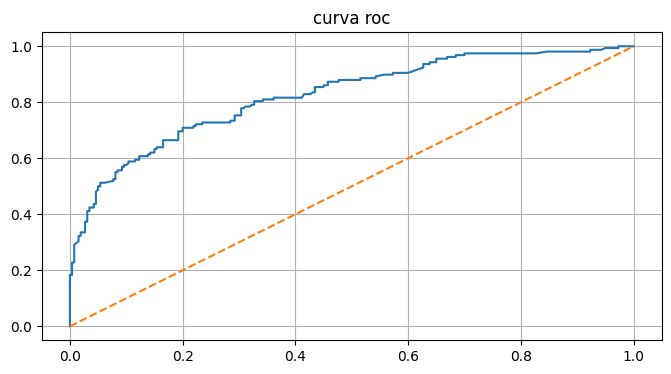

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import matplotlib.pyplot as plt

# Utilizziamo StratifiedKFold per la classificazione binaria
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

ensemble_clf = RandomForestClassifier(random_state=42)

# Griglia di iperparametri seria e accademica
param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
}

grid_search = GridSearchCV(
    estimator=ensemble_clf,
    param_grid=param_grid,
    scoring={"accuracy": "accuracy", "auc": "roc_auc"},
    refit="accuracy",
    cv=cv_strategy,
    n_jobs=-1,
)

grid_search.fit(X_tr_s, y_tr)

best_model = grid_search.best_estimator_
print(f"Migliori parametri: {grid_search.best_params_}")

# Valutazione finale simmetrica (se hai le y_te, altrimenti calcolale sul train/validation)
y_pred = best_model.predict(X_te_s)
y_pred_prob = best_model.predict_proba(X_te_s)[:, 1]


acc = accuracy_score(y_te, y_pred)
score_auc = roc_auc_score(y_te, y_pred_prob)
fpr,tpr, _ = roc_curve(y_te, y_pred_prob)
print(f"Test Accuracy: {acc:.4f}")
print(f"Test AUC: {score_auc:.4f}")

plt.figure(figsize=(8,4))
plt.title('curva roc')
plt.plot(fpr,tpr)
plt.plot([0, 1], [0, 1],linestyle= '--')
plt.grid(True)
plt.show()

